# Cálculo Numérico - EP 4 - Equações Diferenciais
## Item 1: Solução de equações diferenciais ordinárias por Euler e RK4
### Problema I: $\ddot{y} = \dot{y} + y - t^3 -3t^2 + 7t + 1$'

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Definindo funções importantes:

def EDP_euler(t,PVI,h): #PVI = [F(t,Y),t0,Y0], F = (f1,f2,f3...), Y = (y1,y2,y3...)
    func = PVI[0]
    y0 = np.array(PVI[2])
    t0 = PVI[1]
    points = [i for i in np.arange(t0,t+h,h)]
    sol = [y0]
    yi = np.array(y0)
    for ti in points[1:]: #Loop principal. Usei a biblioteca numpy para somar e multiplicar as listas elemento a elemento
        yi = yi + h * np.array(func(ti,yi)) #Fórmula de iteração
        sol.append(yi)
    return [points,np.transpose(np.array(sol))] #Usei a transposta para receber as listas de y1,y2,y3... como solução
    
def EDP_RK4(t,PVI,h): #Mantive exatamente o mesmo formato para os argumentos e saída
    func = PVI[0]
    y0 = np.array(PVI[2])
    t0 = PVI[1]
    points = [i for i in np.arange(t0,t+h,h)]
    sol = [y0]
    yi = np.array(y0)
    for ti in points[1:]: #Loop principal. É a única coisa que muda em relação ao Euler
        k1 = h * np.array(func(ti,yi))
        k2 = h * np.array(func(ti + h / 2. , yi + k1 / 2))
        k3 = h * np.array(func(ti + h / 2. , yi + k2 / 2))
        k4 = h * np.array(func(ti + h , yi + k3))
        yi = yi + 1. / 6. * (k1 + 2 * k2 + 2 * k3 + k4)
        sol.append(yi)
    return [points,np.transpose(np.array(sol))]
    

Agora, resolvendo a equação sugerida $\ddot{y} = \dot{y} + y - t^3 -3t^2 + 7t + 1$

In [3]:
f1 = lambda t,Y: Y[1] #ydot = z
f2 = lambda t,Y: Y[1] + Y[0] - t**3 - 3*t**2 + 7*t + 1
F = lambda t,Y: [f1(t,Y),f2(t,Y)]
Y0 = [0.,-1.]
PVT = (F,0.,Y0)

In [5]:
Sol_Euler = EDP_euler(5.,PVT,0.01)
Sol_Rk = EDP_RK4(5.,PVT,0.01)

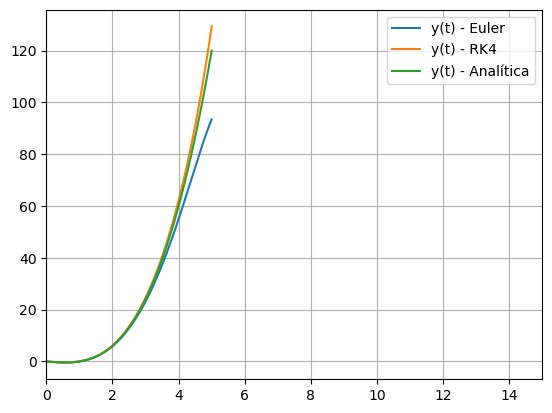

In [6]:
plt.plot(Sol_Euler[0],Sol_Euler[1][0],label = "y(t) - Euler")
plt.plot(Sol_Rk[0],Sol_Rk[1][0], label = "y(t) - RK4")
plt.plot(np.linspace(0,5),[t**3 - t for t in np.linspace(0,5)], label = "y(t) - Analítica")
plt.grid()
plt.xlim([0,15])
plt.legend()

In [7]:
print("y(5)_Euler = ", Sol_Euler[1][0][-1], " dy(5)/dt_Euler = ",Sol_Euler[1][1][-1],"\n"
      "y(5)_RK4 = ", Sol_Rk[1][0][-1], " dy(5)/dt_RK4 = ",Sol_Rk[1][1][-1], "\n"
      "y_Analítica(5) = ", 5**3 - 5, " dy(5)/dt_Analítica = ",3*5**2 - 1)

y(5)_Euler =  93.47110461822129  dy(5)/dt_Euler =  30.40112488917438 
y(5)_RK4 =  129.31987082077814  dy(5)/dt_RK4 =  88.17964425013794 
y_Analítica(5) =  120  dy(5)/dt_Analítica =  74


### Problema II: Potencial de Poço Duplo

#### Potencial simples

In [8]:
F_simples = lambda t , X: [X[1] , 1 / 2 * X[0] * (1 - 4 * X[0]**2)]

X0_simples1 = [-0.5 , 0.1]
X0_simples2 = [-0.5, 0.25]
X0_simples3 = [-0.5, 0.5]

PVI_simples1 = [F_simples, 0., X0_simples1]
PVI_simples2 = [F_simples, 0., X0_simples2]
PVI_simples3 = [F_simples, 0., X0_simples3]

Sol_simples1 = EDP_RK4(40., PVI_simples1, 0.01)
Sol_simples2 = EDP_RK4(40., PVI_simples2, 0.01)
Sol_simples3 = EDP_RK4(40., PVI_simples3, 0.01)

Text(0, 0.5, "x'(t)")

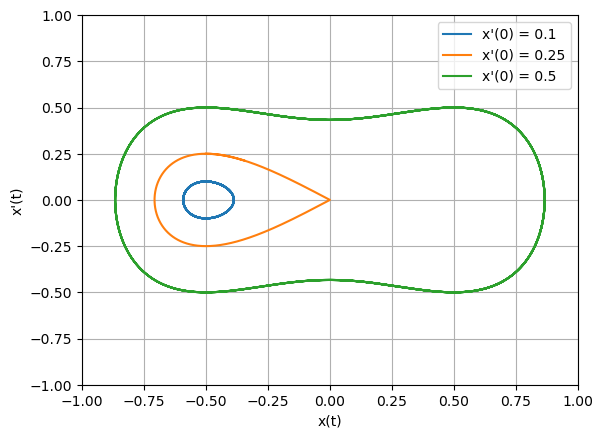

In [9]:
plt.plot(Sol_simples1[1][0],Sol_simples1[1][1], label = "x'(0) = 0.1")
plt.plot(Sol_simples2[1][0],Sol_simples2[1][1], label = "x'(0) = 0.25")
plt.plot(Sol_simples3[1][0],Sol_simples3[1][1], label = "x'(0) = 0.5")
plt.grid()
plt.legend()
plt.ylim([-1,1])
plt.xlim([-1,1])
plt.xlabel("x(t)")
plt.ylabel("x'(t)")

Os atratores nesse caso são as curvas fechadas verde, laranja e azul. Correspondem a movimentos "quase pendulares".

#### Potencial Amortecido: 
$\ddot{y} = \frac{1}{2}x(1-4x^2) - 2\gamma\dot{x}$

In [10]:
F_amortecido1 = lambda t , X: [X[1] , 1 / 2 * X[0] * (1 - 4 * X[0]**2) - 0.25 * X[1]]
F_amortecido2 = lambda t , X: [X[1] , 1 / 2 * X[0] * (1 - 4 * X[0]**2) - 0.8 * X[1]]

X0_amortecido = [-0.5 , 0.5]

PVI_amortecido1 = [F_amortecido1, 0., X0_amortecido]
PVI_amortecido2 = [F_amortecido2, 0., X0_amortecido]

Sol_amortecido1 = EDP_RK4(50., PVI_amortecido1, 0.01)
Sol_amortecido2 = EDP_RK4(50., PVI_amortecido2, 0.01)

Text(0, 0.5, "x'(t)")

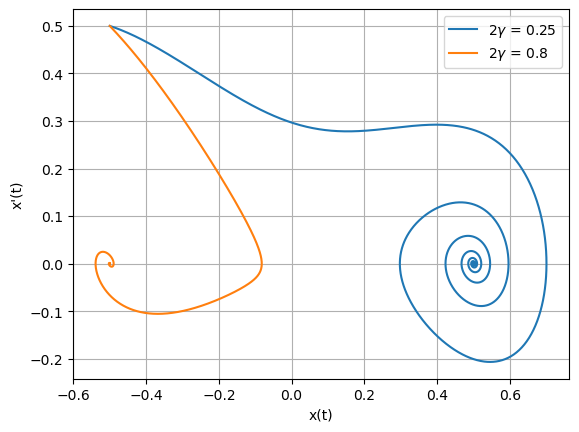

In [11]:
plt.plot(Sol_amortecido1[1][0],Sol_amortecido1[1][1], label = "2$\gamma$ = 0.25")
plt.plot(Sol_amortecido2[1][0],Sol_amortecido2[1][1], label = "2$\gamma$ = 0.8")
plt.grid()
plt.legend()
plt.xlabel("x(t)")
plt.ylabel("x'(t)")

In [12]:
print("O atrator para 2γ = 0.25 é ( x(t -> ∞) , x'(t -> ∞) ) ~ (",Sol_amortecido1[1][0][-1]," , ",Sol_amortecido1[1][1][-1],")\n"
"O atrator para 2γ = 0.8 é ( x(t -> ∞) , x'(t -> ∞) ) ~ (",Sol_amortecido2[1][0][-1]," , ",Sol_amortecido2[1][1][-1],")\n"       )

O atrator para 2γ = 0.25 é ( x(t -> ∞) , x'(t -> ∞) ) ~ ( 0.5006866513773471  ,  -0.0005564759992388328 )
O atrator para 2γ = 0.8 é ( x(t -> ∞) , x'(t -> ∞) ) ~ ( -0.5000000007242712  ,  -4.290269578299326e-09 )



#### Potencial Forçado: 
$\ddot{y} = \frac{1}{2}x(1-4x^2) - 0.25\dot{x} + F\text{cos}(\omega t)$, com $\omega = 1$

In [4]:
F_forçado1 = lambda t , X: [X[1] , 1 / 2 * X[0] * (1 - 4 * X[0]**2) - 0.25 * X[1] + 0.11*np.cos(t)]
F_forçado2 = lambda t , X: [X[1] , 1 / 2 * X[0] * (1 - 4 * X[0]**2) - 0.25 * X[1] + 0.115*np.cos(t)]
F_forçado3 = lambda t , X: [X[1] , 1 / 2 * X[0] * (1 - 4 * X[0]**2) - 0.25 * X[1] + 0.14*np.cos(t)]
F_forçado4 = lambda t , X: [X[1] , 1 / 2 * X[0] * (1 - 4 * X[0]**2) - 0.25 * X[1] + 0.35*np.cos(t)]

X0_forçado = [-0.5 , 0.5]

PVI_forçado1 = [F_forçado1, 0., X0_forçado]
PVI_forçado2 = [F_forçado2, 0., X0_forçado]
PVI_forçado3 = [F_forçado3, 0., X0_forçado]
PVI_forçado4 = [F_forçado4, 0., X0_forçado]

Sol_forçado1 = EDP_RK4(100., PVI_forçado1, 0.01)
Sol_forçado2 = EDP_RK4(100., PVI_forçado2, 0.01)
Sol_forçado3 = EDP_RK4(500., PVI_forçado3, 0.01)
Sol_forçado4 = EDP_RK4(100., PVI_forçado4, 0.01)


KeyboardInterrupt: 

Text(0, 0.5, "x'(t)")

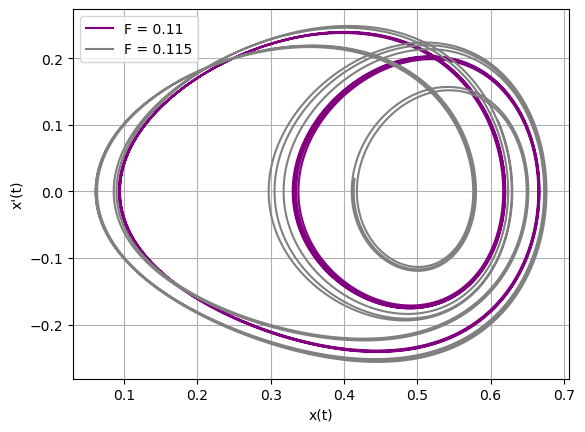

In [14]:
transiente = 3400 #Fui ajustando manualmente até reduzir os caminhos fora dos ciclos
plt.plot(Sol_forçado1[1][0][transiente:],Sol_forçado1[1][1][transiente:], label = "F = 0.11", color = 'purple')
plt.plot(Sol_forçado2[1][0][transiente:],Sol_forçado2[1][1][transiente:], label = "F = 0.115", color = "grey")
plt.grid()
plt.legend()
plt.xlabel("x(t)")
plt.ylabel("x'(t)")

Aqui, os atratores continuam sendo essas curvas quase fechadas que, agora, não representam mais um movimento quase pendular.

Text(0, 0.5, "x'(t)")

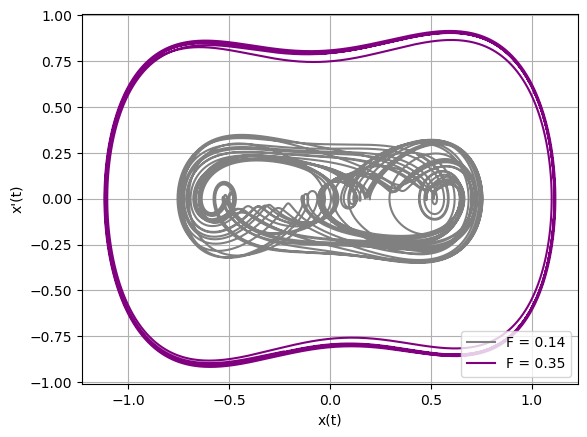

In [15]:
plt.plot(Sol_forçado3[1][0][transiente:],Sol_forçado3[1][1][transiente:], label = "F = 0.14", color = "grey")
plt.plot(Sol_forçado4[1][0][transiente:],Sol_forçado4[1][1][transiente:], label = "F = 0.35", color = 'purple')
plt.grid()
plt.legend()
plt.xlabel("x(t)")
plt.ylabel("x'(t)")

Novamente, os atratores são essas curvas quase fechadas, com destaque a F = 0.14, que representa um movimento bastante complexo

## Item 2: Diagramas de Bifurcação

C:\Users\marco\AppData\Local\Temp\ipykernel_12796\3372808904.py:14: RuntimeWarning: overflow encountered in double_scalars
  yi = yi + F*yi*(1-yi)


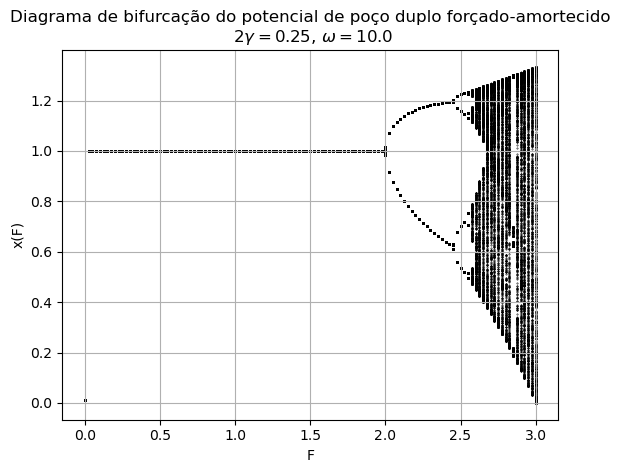

In [107]:
F1list = np.arange(0.,4+0.025,0.025)
x1list = []
y1list = []
for F in F1list:
    #Definições iniciais
    #Func_i = lambda t , X: [X[1] , 1 / 2 * X[0] * (1 - 4 * X[0]**2) - 0.25 * X[1] + F*np.cos(t)]
    y0 = 0.01
    #Loop de 60 períodos após as condições iniciais
    #h = 0.1
    yi = y0
    for n in range(500):
        #y1list.append(yi)
        #x1list.append(F)
        yi = yi + F*yi*(1-yi)
    for n in range(1000):
        y1list.append(yi)
        x1list.append(F)
        yi = yi + F*yi*(1-yi)

plt.scatter(x1list,y1list,color = "black",marker = ".", s = 0.5)
plt.xlabel("F")
plt.ylabel("x(F)")
#plt.ylim([-2.5,2.5])
plt.title("Diagrama de bifurcação do potencial de poço duplo forçado-amortecido\n 2$\gamma = 0.25$, $\omega = 10.0$")
plt.grid()

In [5]:
Flist = np.arange(0.,35+0.05,0.05)
xlist = []
ylist = []
for F in Flist:
    #Definições iniciais
    Func_i = lambda t , X: [X[1] , 1 / 2 * X[0] * (1 - 4 * X[0]**2) - 0.25 * X[1] + F*np.cos(0.75*np.pi*t)]
    Y0 = [-0.5,0.5]
    PVI_i = [Func_i, 0.0 ,Y0]
    h = 0.01*8/3
    #Evolução do transiente
    Sol_transiente = EDP_RK4(h*10000, PVI_i, h)
    #Condições iniciais para o loop
    Yi = [Sol_transiente[1][0][-1],Sol_transiente[1][1][-1]]
    ti = h*10000
    h = 0.001*8/3
    #Loop de 60 períodos após as condições iniciais
    for T in range(50):
        PVI_i = [Func_i, ti, Yi]
        tf = ti + 8./3. #Tempo final = Tempo inicial + 1 período
        Soli = EDP_RK4(tf, PVI_i, h)
        Yi = [Soli[1][0][-1],Soli[1][1][-1]] #Input do próximo loop é o output desse
        ti = tf #Input do próximo loop é o input desse
        xlist.append(F) #Lista dos valores de força (repetidos para facilitar no plot)
        ylist.append(Yi[0]) 
    print("F = ", F)
    

F =  0.0
F =  0.05
F =  0.1
F =  0.15000000000000002
F =  0.2
F =  0.25
F =  0.30000000000000004
F =  0.35000000000000003
F =  0.4
F =  0.45
F =  0.5
F =  0.55
F =  0.6000000000000001
F =  0.65
F =  0.7000000000000001
F =  0.75
F =  0.8
F =  0.8500000000000001
F =  0.9
F =  0.9500000000000001
F =  1.0
F =  1.05
F =  1.1
F =  1.1500000000000001
F =  1.2000000000000002
F =  1.25
F =  1.3
F =  1.35
F =  1.4000000000000001
F =  1.4500000000000002
F =  1.5
F =  1.55
F =  1.6
F =  1.6500000000000001
F =  1.7000000000000002
F =  1.75
F =  1.8
F =  1.85
F =  1.9000000000000001
F =  1.9500000000000002
F =  2.0
F =  2.0500000000000003
F =  2.1
F =  2.15
F =  2.2
F =  2.25
F =  2.3000000000000003
F =  2.35
F =  2.4000000000000004
F =  2.45
F =  2.5
F =  2.5500000000000003
F =  2.6
F =  2.6500000000000004
F =  2.7
F =  2.75
F =  2.8000000000000003
F =  2.85
F =  2.9000000000000004
F =  2.95
F =  3.0
F =  3.0500000000000003
F =  3.1
F =  3.1500000000000004
F =  3.2
F =  3.25
F =  3.3000000000000003

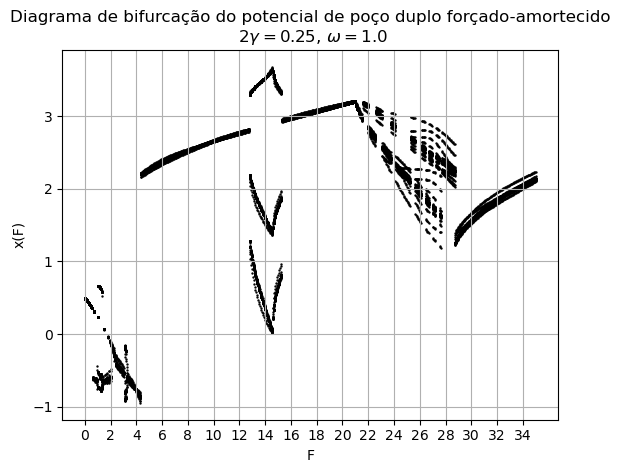

In [6]:
plt.scatter(xlist,ylist,color = "black",marker = ".", s = 2)
plt.xlabel("F")
plt.ylabel("x(F)")
plt.xticks([2*i for i in range(18)])
plt.title("Diagrama de bifurcação do potencial de poço duplo forçado-amortecido\n 2$\gamma = 0.25$, $\omega = 1.0$")
plt.grid()
#plt.xlim([13,26])


In [115]:
f = open("demofile2.txt", "a")
for y in ylist:
    f.write(str(y))
    f.write("\n")
f.close()

Para encontrar a constante de Feigenbaum $\sigma$, eu deveria dividir o valor de F em uma bifurcação pelo valor na anterior, de preferência nas regiões dos valores finais, mas não tenho conseguido um diagrama aceitável e já gastei muitas horas de processamento com isso. Não vou conseguir debuggar tudo a tempo de entregar (faltam 15 minutos para o prazo final). 

In [ ]:
#Mesma função do problema anterior, mas sem o loop sobre as forças
xlistnew = []
ylistnew = []
Func_i = lambda t , X: [X[1] , 1 / 2 * X[0] * (1 - 4 * X[0]**2) - 0.25 * X[1] + 0.26*np.cos(t)]
Y0 = [-0.5,0.5]
PVI_i = [Func_i, 0.0 ,Y0]
h = 2*np.pi*0.01
Sol_transiente = EDP_RK4(h*200000, PVI_i, h)
Yi = [Sol_transiente[1][0][-1],Sol_transiente[1][1][-1]]
ti = h*200000
h = 2*np.pi*0.001
for T in range(100):
    PVI_i = [Func_i, ti, Yi]
    tf = ti + 2*np.pi
    Soli = EDP_RK4(tf, PVI_i, h)
    Yi = [Soli[1][0][-1],Soli[1][1][-1]]
    ti = tf
    xlistnew.append(Yi[0])
    ylistnew.append(Yi[1])

## Item 3: Atratores em cada período

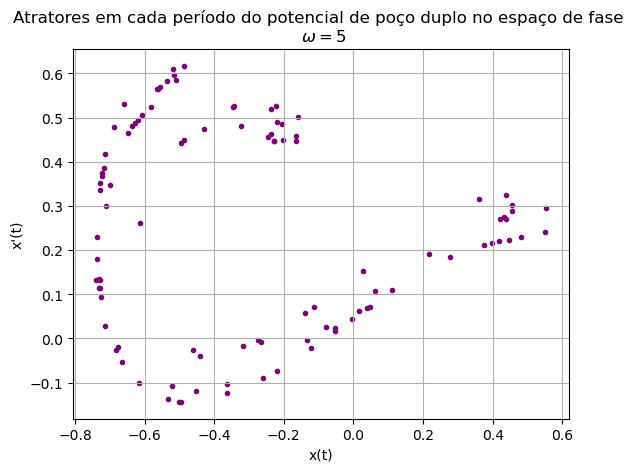

In [117]:
plt.scatter(xlistnew,ylistnew,color = "purple",marker = ".")
plt.xlabel("x(t)")
plt.ylabel("x'(t)")
plt.title("Atratores em cada período do potencial de poço duplo no espaço de fase \n $\omega = 5$")
plt.grid()
plt.show()
